# 03 — Bayesian Sequential Update: Predict & Update

> **Module:** `00-foundations/probabilities-estimation`  
> **Prerequisites:** `01_bayes_intro.ipynb`, `02_gaussian_distributions.ipynb`  
> **Time:** ~3h  

---

## What this notebook builds

In notebook 01 we learned *why* we fuse distributions (Bayes).  
In notebook 02 we learned *which* distributions we will use (Gaussians) and their properties.  

This notebook builds the **recursive structure** that is the heart of every filter in this roadmap.

A moving drone cannot be tracked with a single Bayesian update. It requires a **loop**:

```
┌─────────────────────────────────────────────┐
│  At each time step k:                       │
│                                             │
│  1. PREDICT  ── use motion model ──►  x̂⁻   │
│  2. UPDATE   ── use measurement  ──►  x̂    │
│  3. Go to step 1 with new prior             │
└─────────────────────────────────────────────┘
```

By the end of this notebook you will have built this loop from scratch — without yet calling it a Kalman filter. That formalisation comes in Module 01.

---

## Learning objectives

1. Implement the predict–update cycle for a 1D Gaussian estimator
2. Understand how uncertainty evolves: grows during prediction, shrinks during update
3. Identify the role of process noise Q and measurement noise R
4. Analyse filter behaviour under different Q/R ratios
5. Recognise the predict–update structure as the skeleton of the Kalman filter


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)

---
## Part 1 — The two-step structure

### The problem

A drone moves along a straight corridor. At each second:
- It moves forward by approximately 2 m (with some uncertainty — motors are not perfect)
- A GPS sensor gives a noisy position reading

We want to estimate the true position as accurately as possible at each step.

### State and parameters

| Symbol | Meaning | Value |
|--------|---------|-------|
| $x_k$ | True position at step $k$ (m) | unknown |
| $\hat{x}_k$ | Estimated position | what we compute |
| $P_k$ | Variance of estimate | what we track |
| $u$ | Expected displacement per step (m) | 2.0 |
| $Q$ | Process noise variance — motion uncertainty (m²) | tunable |
| $R$ | Measurement noise variance — GPS noise (m²) | tunable |

### The two steps — Gaussian form

**Step 1 — Predict** (propagate state forward in time):

$$\hat{x}_k^- = \hat{x}_{k-1} + u$$
$$P_k^- = P_{k-1} + Q$$

**Step 2 — Update** (incorporate GPS measurement $z_k$):

$$K_k = \frac{P_k^-}{P_k^- + R}$$
$$\hat{x}_k = \hat{x}_k^- + K_k (z_k - \hat{x}_k^-)$$
$$P_k = (1 - K_k)\, P_k^-$$

That is all. The Kalman filter (Module 01) is the same structure, extended to multiple dimensions and with a proper derivation of why these exact equations follow from Bayesian inference.


---
## Part 2 — Implementing the filter


In [3]:
# ─── Simulation parameters ───────────────────────────────────────────────────
N_STEPS   = 30          # number of time steps
U         = 2.0         # true displacement per step (m)
Q         = 0.5         # process noise variance (m²) — motion uncertainty
R         = 4.0         # measurement noise variance (m²) — GPS noise
X0_TRUE   = 0.0         # true initial position
X0_EST    = 0.0         # initial estimate
P0        = 5.0         # initial variance


def simulate_drone(n_steps, u, Q, R, x0=0.0, seed=42):
    """Simulate drone motion + noisy GPS measurements."""
    rng = np.random.default_rng(seed)
    true_positions = np.zeros(n_steps + 1)
    measurements   = np.zeros(n_steps + 1)
    true_positions[0] = x0
    measurements[0]   = x0 + rng.normal(0, np.sqrt(R))
    for k in range(1, n_steps + 1):
        # True motion: nominal + process noise
        true_positions[k] = true_positions[k-1] + u + rng.normal(0, np.sqrt(Q))
        # GPS measurement: true position + measurement noise
        measurements[k]   = true_positions[k] + rng.normal(0, np.sqrt(R))
    return true_positions, measurements


def bayesian_sequential_filter(measurements, u, Q, R, x0_est, P0):
    """
    1D Gaussian predict–update filter.
    Returns: estimates, variances, predicted_estimates, predicted_variances, kalman_gains
    """
    n = len(measurements)
    x_est  = np.zeros(n)   # posterior mean
    P_est  = np.zeros(n)   # posterior variance
    x_pred = np.zeros(n)   # prior mean (after predict)
    P_pred = np.zeros(n)   # prior variance (after predict)
    K_hist = np.zeros(n)   # Kalman gain history

    # Initialise
    x_est[0]  = x0_est
    P_est[0]  = P0
    x_pred[0] = x0_est
    P_pred[0] = P0

    for k in range(1, n):
        # ── PREDICT ──────────────────────────────────
        x_pred[k] = x_est[k-1] + u       # state propagation
        P_pred[k] = P_est[k-1] + Q       # covariance grows with motion uncertainty

        # ── UPDATE ───────────────────────────────────
        K          = P_pred[k] / (P_pred[k] + R)          # Kalman gain
        x_est[k]   = x_pred[k] + K * (measurements[k] - x_pred[k])  # update mean
        P_est[k]   = (1 - K) * P_pred[k]                  # update variance
        K_hist[k]  = K

    return x_est, P_est, x_pred, P_pred, K_hist


# Run simulation and filter
true_pos, measurements = simulate_drone(N_STEPS, U, Q, R, X0_TRUE)
x_est, P_est, x_pred, P_pred, K_hist = bayesian_sequential_filter(
    measurements, U, Q, R, X0_EST, P0
)

steps = np.arange(N_STEPS + 1)
sigma_est  = np.sqrt(P_est)
sigma_pred = np.sqrt(P_pred)

print(f"Filter parameters: Q={Q}, R={R}")
print(f"Final estimate std:  {sigma_est[-1]:.3f} m")
print(f"Final Kalman gain:   {K_hist[-1]:.3f}  (0=trust model, 1=trust sensor)")
print(f"RMSE vs true position: {np.sqrt(np.mean((x_est - true_pos)**2)):.3f} m")
print(f"RMSE of raw GPS:       {np.sqrt(np.mean((measurements - true_pos)**2)):.3f} m")

Filter parameters: Q=0.5, R=4.0
Final estimate std:  1.089 m
Final Kalman gain:   0.297  (0=trust model, 1=trust sensor)
RMSE vs true position: 1.009 m
RMSE of raw GPS:       1.715 m


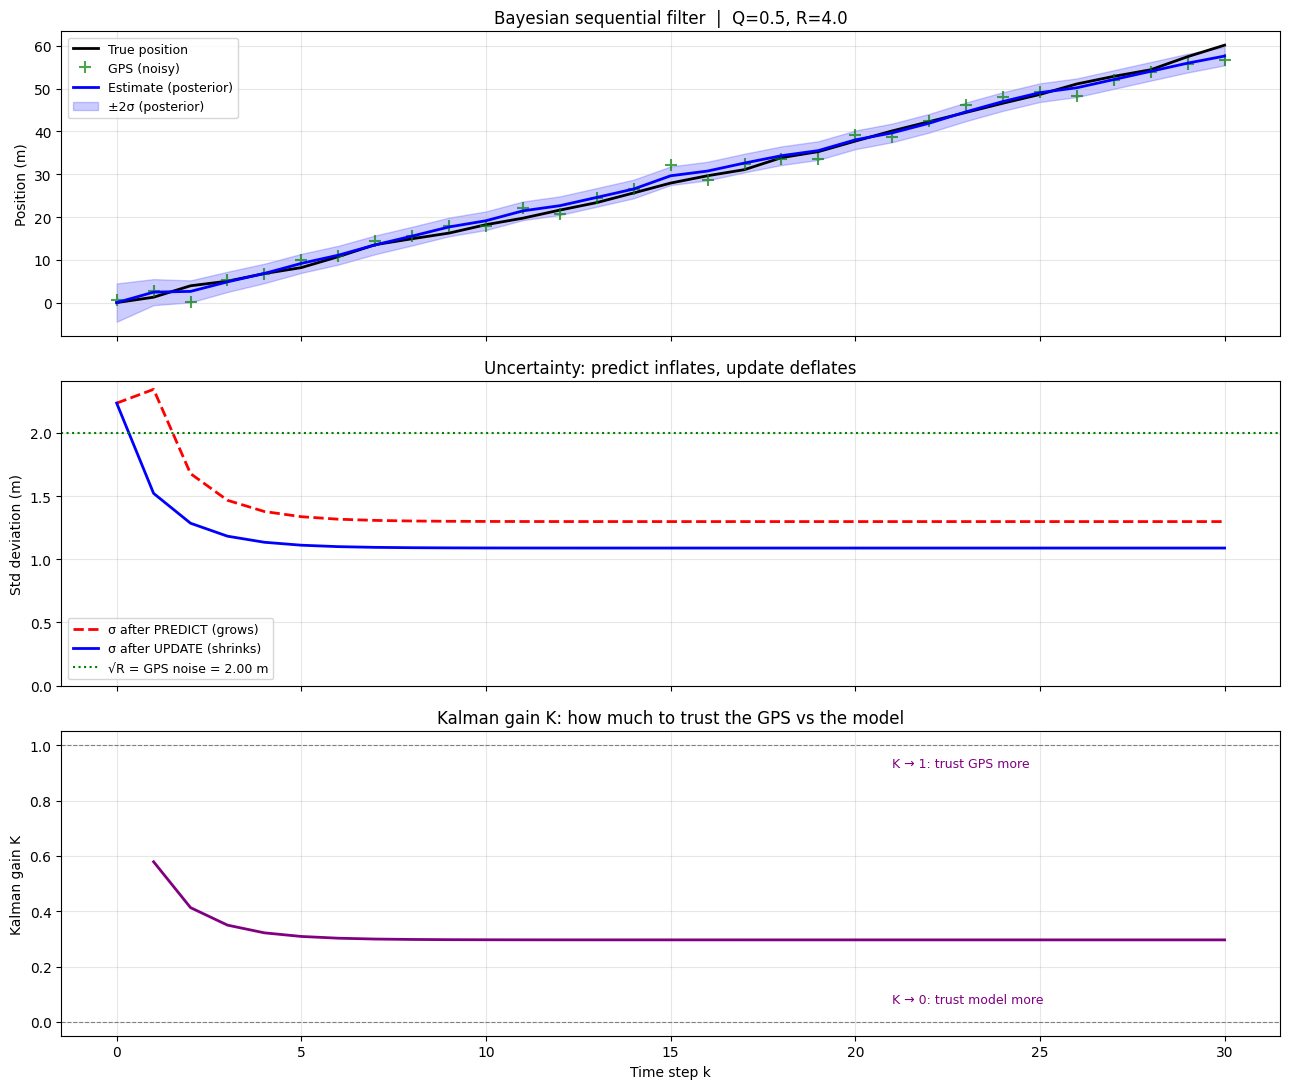

In [5]:
# ─── Main result plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# Top: positions
ax = axes[0]
ax.plot(steps, true_pos,    'k-',  linewidth=2,   label='True position')
ax.plot(steps, measurements,'g+',  markersize=8,  markeredgewidth=1.5, label='GPS (noisy)', alpha=0.7)
ax.plot(steps, x_est,       'b-',  linewidth=2,   label='Estimate (posterior)')
ax.fill_between(steps,
                x_est - 2*sigma_est,
                x_est + 2*sigma_est,
                alpha=0.2, color='blue', label='±2σ (posterior)')
ax.set_ylabel('Position (m)')
ax.set_title(f'Bayesian sequential filter  |  Q={Q}, R={R}', fontsize=12)
ax.legend(fontsize=9, loc='upper left')

# Middle: uncertainty evolution
ax = axes[1]
ax.plot(steps, sigma_pred, 'r--', linewidth=2, label='σ after PREDICT (grows)')
ax.plot(steps, sigma_est,  'b-',  linewidth=2, label='σ after UPDATE (shrinks)')
ax.axhline(np.sqrt(R), color='green', linestyle=':', linewidth=1.5, label=f'√R = GPS noise = {np.sqrt(R):.2f} m')
ax.set_ylabel('Std deviation (m)')
ax.set_title('Uncertainty: predict inflates, update deflates')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# Bottom: Kalman gain
ax = axes[2]
ax.plot(steps[1:], K_hist[1:], 'purple', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Kalman gain K')
ax.set_xlabel('Time step k')
ax.set_title('Kalman gain K: how much to trust the GPS vs the model')
ax.set_ylim(-0.05, 1.05)
ax.text(N_STEPS*0.7, 0.92, 'K → 1: trust GPS more', fontsize=9, color='purple')
ax.text(N_STEPS*0.7, 0.07, 'K → 0: trust model more', fontsize=9, color='purple')

plt.tight_layout()
plt.show()

---
## Part 3 — Anatomy of one step

Let us slow down and watch a single predict–update cycle in detail.


Step k=5:
  Prior (after predict):  μ = 8.815, σ = 1.337
  GPS measurement:        z = 9.941
  Kalman gain:            K = 0.309
  Posterior (after update): μ = 9.163, σ = 1.112
  True position: 8.182


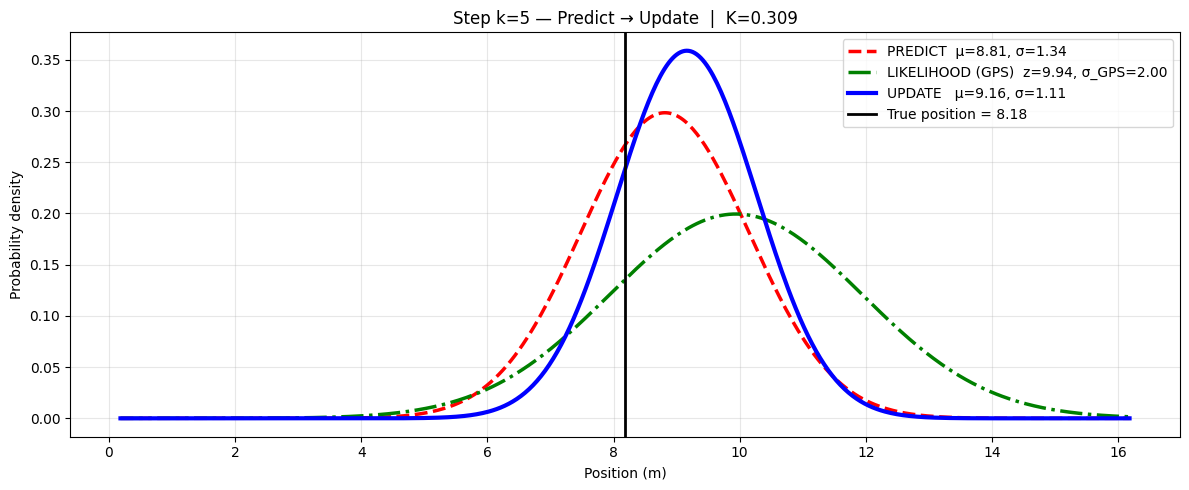

In [7]:
def plot_single_step(k, x_post_prev, P_post_prev, z_k, true_k, u, Q, R):
    """Visualise one predict–update cycle as Gaussian distributions."""

    # Predict
    x_prior = x_post_prev + u
    P_prior  = P_post_prev + Q

    # Update
    K       = P_prior / (P_prior + R)
    x_post  = x_prior + K * (z_k - x_prior)
    P_post  = (1 - K) * P_prior

    # Plot range
    center = true_k
    width  = 4 * max(np.sqrt(P_prior), np.sqrt(R))
    x_range = np.linspace(center - width, center + width, 500)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(x_range, norm.pdf(x_range, x_prior, np.sqrt(P_prior)),
            'r--', linewidth=2.5, label=f'PREDICT  μ={x_prior:.2f}, σ={np.sqrt(P_prior):.2f}')
    ax.plot(x_range, norm.pdf(x_range, z_k, np.sqrt(R)),
            'g-.', linewidth=2.5, label=f'LIKELIHOOD (GPS)  z={z_k:.2f}, σ_GPS={np.sqrt(R):.2f}')
    ax.plot(x_range, norm.pdf(x_range, x_post, np.sqrt(P_post)),
            'b-',  linewidth=3,   label=f'UPDATE   μ={x_post:.2f}, σ={np.sqrt(P_post):.2f}')

    ax.axvline(true_k, color='black', linewidth=2, label=f'True position = {true_k:.2f}')

    ax.set_xlabel('Position (m)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Step k={k} — Predict → Update  |  K={K:.3f}')
    ax.legend(fontsize=10)

    print(f"Step k={k}:")
    print(f"  Prior (after predict):  μ = {x_prior:.3f}, σ = {np.sqrt(P_prior):.3f}")
    print(f"  GPS measurement:        z = {z_k:.3f}")
    print(f"  Kalman gain:            K = {K:.3f}")
    print(f"  Posterior (after update): μ = {x_post:.3f}, σ = {np.sqrt(P_post):.3f}")
    print(f"  True position: {true_k:.3f}")
    plt.tight_layout()
    plt.show()


# Show step k=5 in detail
k_show = 5
plot_single_step(
    k=k_show,
    x_post_prev=x_est[k_show - 1],
    P_post_prev=P_est[k_show - 1],
    z_k=measurements[k_show],
    true_k=true_pos[k_show],
    u=U, Q=Q, R=R
)

---
## Part 4 — The role of Q and R

Q and R are the two knobs that control filter behaviour.

| Q large | Q small |
|---------|---------|
| Model is uncertain (drone drifts a lot) | Model is trusted (very predictable motion) |
| Predict inflates P rapidly | Predict inflates P slowly |
| K stays high → listens to GPS more | K stays low → relies on model more |

| R large | R small |
|---------|---------|
| GPS is noisy | GPS is precise |
| K is small → GPS contributes less | K is large → GPS dominates |

The ratio Q/R determines the **steady-state Kalman gain**.


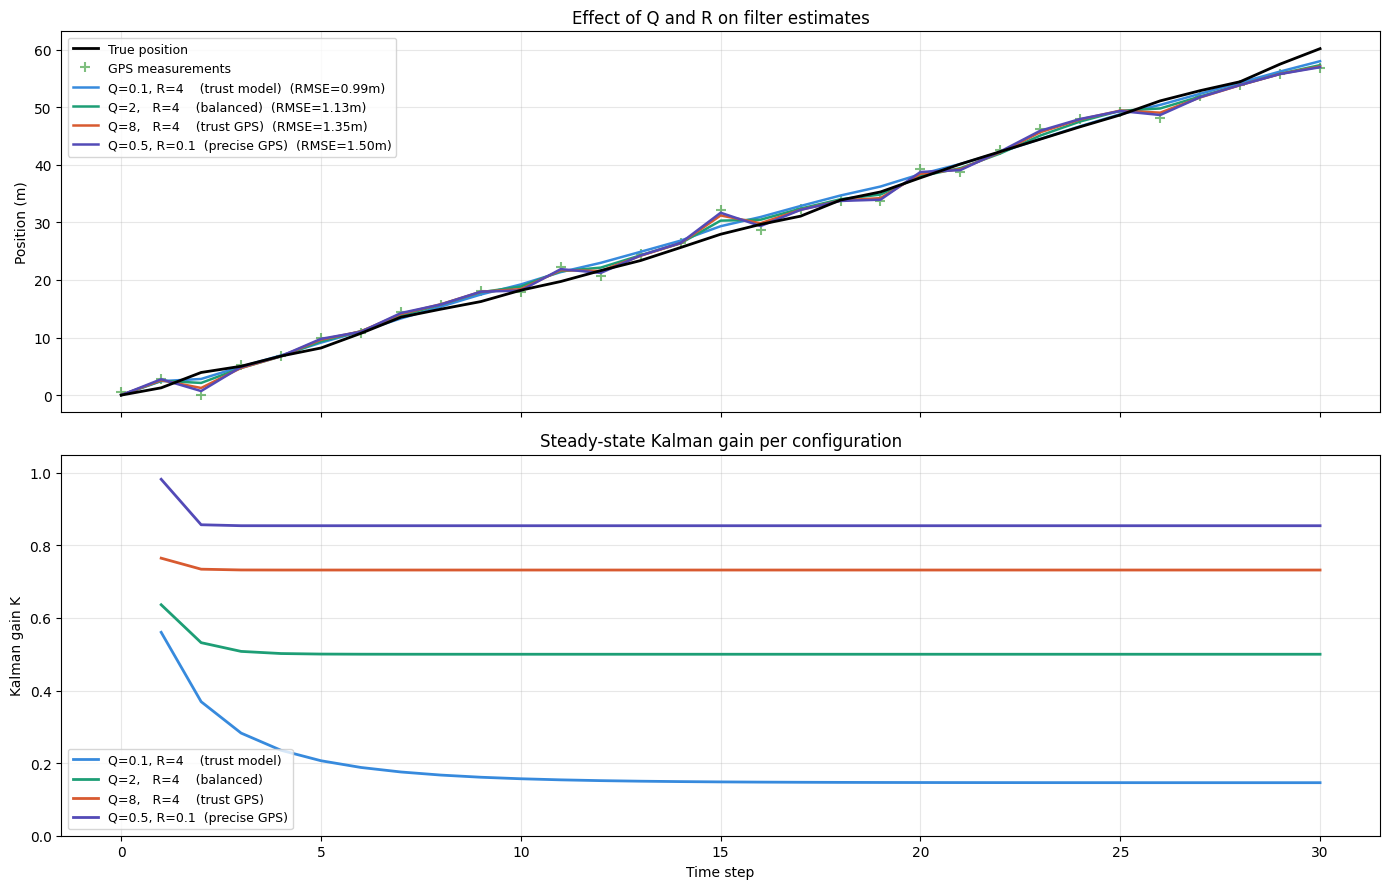

In [9]:
# Compare 4 Q/R configurations on the same trajectory
configs = [
    {'Q': 0.1,  'R': 4.0,  'label': 'Q=0.1, R=4    (trust model)', 'color': '#378ADD'},
    {'Q': 2.0,  'R': 4.0,  'label': 'Q=2,   R=4    (balanced)',     'color': '#1D9E75'},
    {'Q': 8.0,  'R': 4.0,  'label': 'Q=8,   R=4    (trust GPS)',    'color': '#D85A30'},
    {'Q': 0.5,  'R': 0.1,  'label': 'Q=0.5, R=0.1  (precise GPS)', 'color': '#534AB7'},
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(steps, true_pos, 'k-', linewidth=2, label='True position', zorder=5)
axes[0].plot(steps, measurements, 'g+', markersize=7, markeredgewidth=1.5,
             alpha=0.5, label='GPS measurements')

for cfg in configs:
    xe, Pe, _, _, Kh = bayesian_sequential_filter(
        measurements, U, cfg['Q'], cfg['R'], X0_EST, P0
    )
    se = np.sqrt(Pe)
    rmse = np.sqrt(np.mean((xe - true_pos)**2))

    axes[0].plot(steps, xe, linewidth=1.8, color=cfg['color'],
                 label=f"{cfg['label']}  (RMSE={rmse:.2f}m)")
    axes[1].plot(steps[1:], Kh[1:], linewidth=2, color=cfg['color'],
                 label=cfg['label'])

axes[0].set_ylabel('Position (m)')
axes[0].set_title('Effect of Q and R on filter estimates')
axes[0].legend(fontsize=9, loc='upper left')

axes[1].set_ylabel('Kalman gain K')
axes[1].set_xlabel('Time step')
axes[1].set_title('Steady-state Kalman gain per configuration')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## Part 5 — What happens without GPS? (prediction only)

This simulates **dead reckoning** — what the filter does when GPS drops out.  
Uncertainty grows indefinitely. This motivates why sensor fusion is essential.


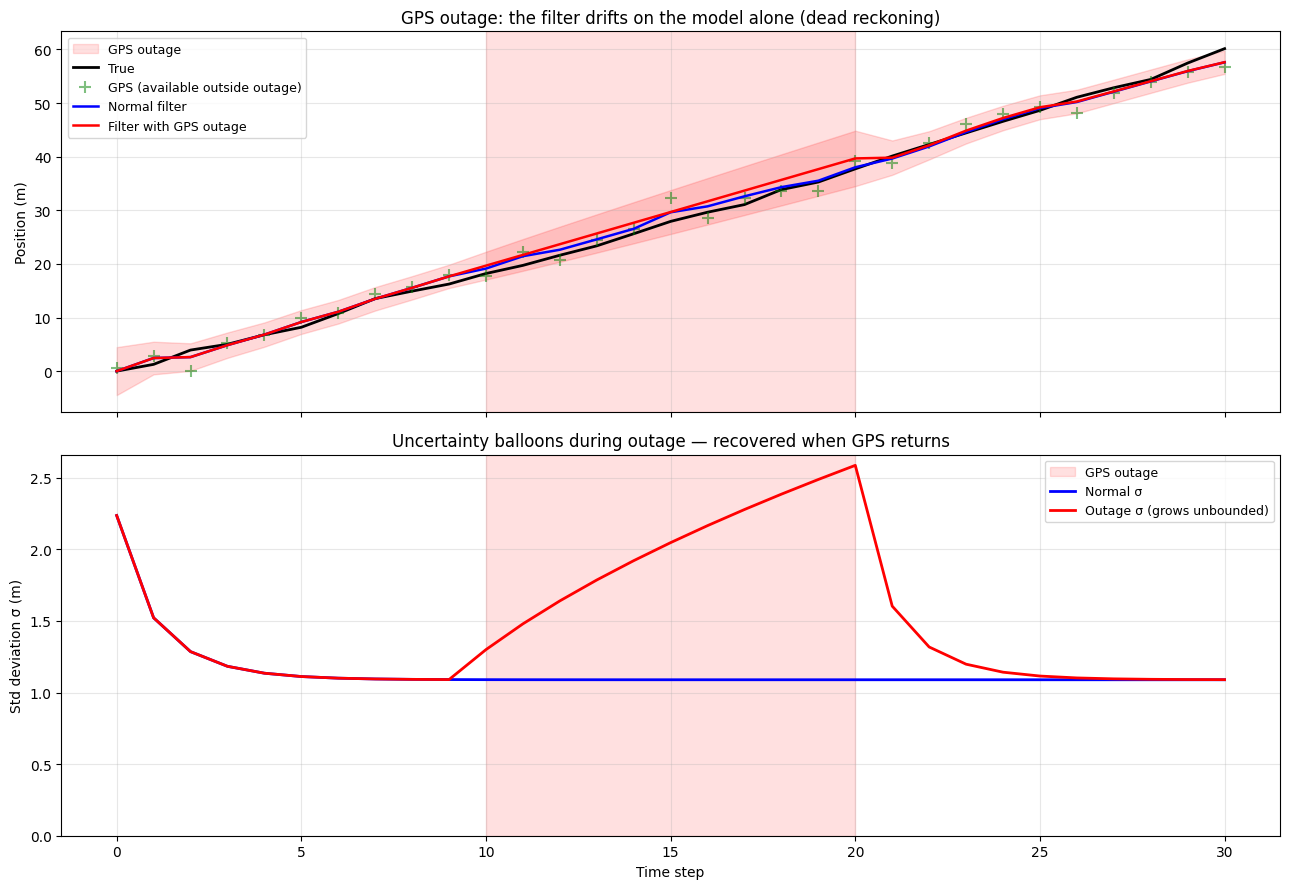

Max std during outage: 2.59 m
Std at end of outage:  2.59 m
Std 5 steps after GPS returns: 1.12 m
→ Filter self-corrects once measurements resume


In [11]:
def filter_with_gps_outage(measurements, u, Q, R, x0_est, P0,
                            outage_start=10, outage_end=20):
    """Filter with a GPS dropout between outage_start and outage_end."""
    n = len(measurements)
    x_est = np.zeros(n)
    P_est = np.zeros(n)
    x_est[0], P_est[0] = x0_est, P0

    for k in range(1, n):
        # Predict
        x_pred = x_est[k-1] + u
        P_pred = P_est[k-1] + Q

        if outage_start <= k <= outage_end:
            # GPS unavailable — keep prediction as estimate
            x_est[k] = x_pred
            P_est[k] = P_pred
        else:
            # Normal update
            K = P_pred / (P_pred + R)
            x_est[k] = x_pred + K * (measurements[k] - x_pred)
            P_est[k] = (1 - K) * P_pred

    return x_est, P_est


OUTAGE_START, OUTAGE_END = 10, 20

x_normal, P_normal = bayesian_sequential_filter(
    measurements, U, Q, R, X0_EST, P0
)[:2]

x_outage, P_outage = filter_with_gps_outage(
    measurements, U, Q, R, X0_EST, P0,
    outage_start=OUTAGE_START, outage_end=OUTAGE_END
)

s_normal = np.sqrt(P_normal)
s_outage = np.sqrt(P_outage)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Shade outage region
for ax in axes:
    ax.axvspan(OUTAGE_START, OUTAGE_END, alpha=0.12, color='red', label='GPS outage')

# Position
axes[0].plot(steps, true_pos, 'k-', linewidth=2, label='True')
axes[0].plot(steps, measurements, 'g+', markersize=8, markeredgewidth=1.5, alpha=0.5,
             label='GPS (available outside outage)')
axes[0].plot(steps, x_normal, 'b-', linewidth=1.8, label='Normal filter')
axes[0].plot(steps, x_outage, 'r-', linewidth=1.8, label='Filter with GPS outage')
axes[0].fill_between(steps, x_outage - 2*s_outage, x_outage + 2*s_outage,
                     alpha=0.15, color='red')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('GPS outage: the filter drifts on the model alone (dead reckoning)')
axes[0].legend(fontsize=9)

# Uncertainty
axes[1].plot(steps, s_normal, 'b-', linewidth=2, label='Normal σ')
axes[1].plot(steps, s_outage, 'r-', linewidth=2, label='Outage σ (grows unbounded)')
axes[1].set_ylabel('Std deviation σ (m)')
axes[1].set_xlabel('Time step')
axes[1].set_title('Uncertainty balloons during outage — recovered when GPS returns')
axes[1].legend(fontsize=9)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"Max std during outage: {s_outage[OUTAGE_START:OUTAGE_END+1].max():.2f} m")
print(f"Std at end of outage:  {s_outage[OUTAGE_END]:.2f} m")
print(f"Std 5 steps after GPS returns: {s_outage[OUTAGE_END+5]:.2f} m")
print("→ Filter self-corrects once measurements resume")

---
## Part 6 — Filter consistency

How do we know the filter is working correctly?

A **consistent** filter means: the true state falls within the estimated uncertainty bounds at the expected rate.

Specifically, the **normalised estimation error** $\epsilon_k = (x_k - \hat{x}_k) / \sqrt{P_k}$ should follow $\mathcal{N}(0,1)$.

- **Overconfident filter** (P too small): $|\epsilon_k|$ is often > 2 — the true state lies outside the 2σ band more than 5% of the time
- **Underconfident filter** (P too large): $|\epsilon_k|$ is always very small — the filter is pessimistic
- **Consistent filter**: $\epsilon_k \sim \mathcal{N}(0,1)$ — uncertainty matches reality

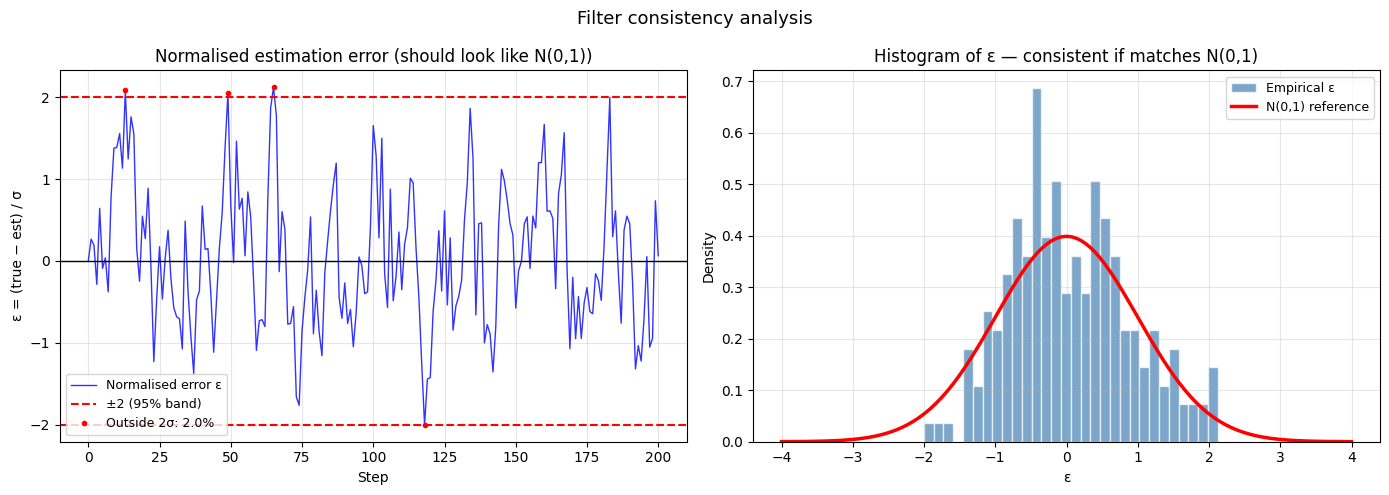

Mean of ε:   0.0568  (should be ≈ 0)
Std of ε:    0.8502  (should be ≈ 1)
% outside 2σ: 2.0%  (should be ≈ 5%)


In [14]:
# Run a longer simulation to assess consistency statistically
N_LONG = 200
true_long, meas_long = simulate_drone(N_LONG, U, Q, R, X0_TRUE, seed=7)
xe_long, Pe_long = bayesian_sequential_filter(
    meas_long, U, Q, R, X0_EST, P0
)[:2]

# Normalised error
eps = (true_long - xe_long) / np.sqrt(Pe_long)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series of normalised error
ax = axes[0]
ax.plot(eps, 'b-', linewidth=1, alpha=0.8, label='Normalised error ε')
ax.axhline(0,   color='black',  linewidth=1)
ax.axhline(+2,  color='red',    linewidth=1.5, linestyle='--', label='±2 (95% band)')
ax.axhline(-2,  color='red',    linewidth=1.5, linestyle='--')
outside = np.abs(eps) > 2
ax.plot(np.where(outside)[0], eps[outside], 'r.', markersize=6, label=f'Outside 2σ: {outside.mean()*100:.1f}%')
ax.set_xlabel('Step')
ax.set_ylabel('ε = (true − est) / σ')
ax.set_title('Normalised estimation error (should look like N(0,1))')
ax.legend(fontsize=9)

# Histogram vs N(0,1)
ax = axes[1]
x_ref = np.linspace(-4, 4, 200)
ax.hist(eps, bins=30, density=True, color='steelblue', alpha=0.7,
        edgecolor='white', label='Empirical ε')
ax.plot(x_ref, norm.pdf(x_ref), 'r-', linewidth=2.5, label='N(0,1) reference')
ax.set_xlabel('ε')
ax.set_ylabel('Density')
ax.set_title('Histogram of ε — consistent if matches N(0,1)')
ax.legend(fontsize=9)

plt.suptitle('Filter consistency analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean of ε:   {eps.mean():.4f}  (should be ≈ 0)")
print(f"Std of ε:    {eps.std():.4f}  (should be ≈ 1)")
print(f"% outside 2σ: {outside.mean()*100:.1f}%  (should be ≈ 5%)")

---
## Part 7 — Connecting to the Kalman filter

Everything built in this notebook is the Kalman filter — just in 1D, scalar form.

The full Kalman filter (Module 01) is the same structure, extended to:
- **Vector states** $\mathbf{x} \in \mathbb{R}^n$ (position + velocity + orientation...)
- **Matrix covariances** $\mathbf{P} \in \mathbb{R}^{n \times n}$
- **Matrix gains** $\mathbf{K} \in \mathbb{R}^{n \times m}$
- **Measurement models** $\mathbf{H}$ (sensor may not observe all state components)

| This notebook | Kalman filter (Module 01) |
|--------------|---------------------------|
| $\hat{x}^- = \hat{x} + u$ | $\hat{\mathbf{x}}^- = \mathbf{A}\hat{\mathbf{x}} + \mathbf{B}\mathbf{u}$ |
| $P^- = P + Q$ | $\mathbf{P}^- = \mathbf{A}\mathbf{P}\mathbf{A}^T + \mathbf{Q}$ |
| $K = P^- / (P^- + R)$ | $\mathbf{K} = \mathbf{P}^-\mathbf{H}^T(\mathbf{H}\mathbf{P}^-\mathbf{H}^T + \mathbf{R})^{-1}$ |
| $\hat{x} = \hat{x}^- + K(z - \hat{x}^-)$ | $\hat{\mathbf{x}} = \hat{\mathbf{x}}^- + \mathbf{K}(\mathbf{z} - \mathbf{H}\hat{\mathbf{x}}^-)$ |
| $P = (1-K)P^-$ | $\mathbf{P} = (\mathbf{I} - \mathbf{K}\mathbf{H})\mathbf{P}^-$ |

The scalar $P$ becomes a matrix $\mathbf{P}$. The scalar $K$ becomes a matrix $\mathbf{K}$.  
The loop structure — predict, update, repeat — is **identical**.


---
## Exercises

### Exercise 1 — Steady-state Kalman gain

For large $k$, the Kalman gain converges to a steady-state value $K_\infty$.

At steady state, $P^- = P + Q$ and $P = (1-K)P^-$, which gives the equation:

$$P_\infty = \frac{-Q + \sqrt{Q^2 + 4QR}}{2}$$

**Q1:** Derive this formula from the predict and update equations.  
**Q2:** Compute $P_\infty$ and $K_\infty$ for the four configurations in Part 4.  
**Q3:** Verify numerically that the filter converges to these values.

In [ ]:
# Exercise 1
def steady_state_gain(Q, R):
    """TODO: implement steady-state variance and Kalman gain."""
    P_inf = None   # replace
    K_inf = None   # replace
    return P_inf, K_inf

for cfg in configs:
    P_inf, K_inf = steady_state_gain(cfg['Q'], cfg['R'])
    print(f"Q={cfg['Q']:4.1f}, R={cfg['R']:4.1f}  →  P_∞={P_inf}, K_∞={K_inf}")

### Exercise 2 — Two sensors

Your drone now has **two** position sensors:
- GPS: $R_1 = 4.0$ m²
- UWB (ultra-wideband indoor): $R_2 = 0.25$ m²

**Q1:** Modify `bayesian_sequential_filter` to fuse two measurements per step.  
**Hint:** Apply two sequential update steps — first with GPS, then with UWB.  
**Q2:** Compare RMSE with GPS-only, UWB-only, and GPS+UWB fusion.  
**Q3:** What happens if one sensor has a systematic bias (+2 m)? How does the filter react?

In [ ]:
# Exercise 2
R_gps = 4.0
R_uwb = 0.25
np.random.seed(42)

# Simulate two sensors
gps_measurements = true_pos + np.random.normal(0, np.sqrt(R_gps), len(true_pos))
uwb_measurements = true_pos + np.random.normal(0, np.sqrt(R_uwb), len(true_pos))

# TODO: implement two-sensor fusion
def filter_two_sensors(gps, uwb, u, Q, R_gps, R_uwb, x0, P0):
    pass  # your implementation here

### Exercise 3 — Divergence diagnosis

Run the filter with **Q=0.001, R=4.0** (severely underestimated process noise).

**Q1:** Plot the normalised error $\epsilon_k$. What do you observe?  
**Q2:** What percentage of steps fall outside the 2σ band?  
**Q3:** What does this tell you about the filter's estimate of its own uncertainty?  
**Q4:** Propose a Q value that restores consistency and justify your choice.

In [ ]:
# Exercise 3
Q_bad = 0.001

xe_bad, Pe_bad = bayesian_sequential_filter(
    meas_long, U, Q_bad, R, X0_EST, P0
)[:2]

# TODO: compute and plot normalised error
# TODO: compare with well-tuned filter

---
## Summary

| Concept | Key insight |
|---------|------------|
| Predict step | Uncertainty **grows** — motion model is imperfect |
| Update step | Uncertainty **shrinks** — measurement adds information |
| Kalman gain K | Ratio: how much to trust measurement vs model |
| Q/R ratio | The single most important tuning decision |
| GPS outage | Predict-only → dead reckoning → drift |
| Consistency | $\epsilon \sim \mathcal{N}(0,1)$ — filter is neither over- nor underconfident |

---

## What comes next

The `00-foundations` module continues with:

- `linear-algebra/01_matrix_operations.ipynb` — the tools needed to extend scalar → matrix
- `linear-algebra/02_eigenvalues_geometry.ipynb` — understanding P as a geometric object
- `linear-algebra/03_positive_definite_matrices.ipynb` — why P must be PD and how to maintain it

Then `signals-and-noise/` and `state-space-models/` before the full Kalman filter derivation in Module 01.